# Binary Classification
---

## Anti-spam model
Vogliamo capire se una recensione è stata lasciata avendo acquistato il prodotto oppure no.
Nel dettaglio, abbiamo pensato di capire tramite un modello se una review pubblicata sembra essere accompagnata dall'acquisto del telefono. <br>
<br>
Questo sistema può essere visto come "anti-spam" perchè una volta ricevuta una recensione che pare avere un forte bias, il modello può verificare se la recensione sembra non accompagnata da un acquisto, e messo in parallelo a qualche software potrebbe mandare una richiesta all'autore della review, per intimare di verificare l'acquisto tramite foto.<br>
Questo porterebbe utenti malevoli a non lasciare recensioni senza poter verificare di avere effettivamente provato il prodotto.

### Import file

In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("./data/Mobile Reviews Sentiment.csv")

In [31]:
#verifiche riguardo al dataset
print(df["sentiment"].unique())


['Negative' 'Positive' 'Neutral']


In [32]:
num_features = [
    "rating",
    "battery_life_rating",
    "camera_rating",
    "performance_rating",
    "design_rating",
    "display_rating",
]

cat_features = ["sentiment"]

TARGET = "verified_purchase"

X = df[num_features + cat_features].copy()
y = df[TARGET].astype(int)
X = pd.get_dummies(X, columns=["sentiment"], drop_first=True)
print(X.shape, y.shape)
print(X.head())


(50000, 8) (50000,)
   rating  battery_life_rating  camera_rating  performance_rating  \
0       2                    1              1                   3   
1       4                    3              2                   4   
2       4                    3              5                   3   
3       3                    1              3                   2   
4       3                    3              3                   2   

   design_rating  display_rating  sentiment_Neutral  sentiment_Positive  
0              2               1              False               False  
1              3               2              False                True  
2              2               4              False                True  
3              1               2              False                True  
4              2               1               True               False  


verified_purchase      1.000000
sentiment_Neutral      0.001299
performance_rating     0.001071
display_rating        -0.000841
rating                -0.000860
camera_rating         -0.001187
design_rating         -0.002328
battery_life_rating   -0.002612
sentiment_Positive    -0.002878
Name: verified_purchase, dtype: float64


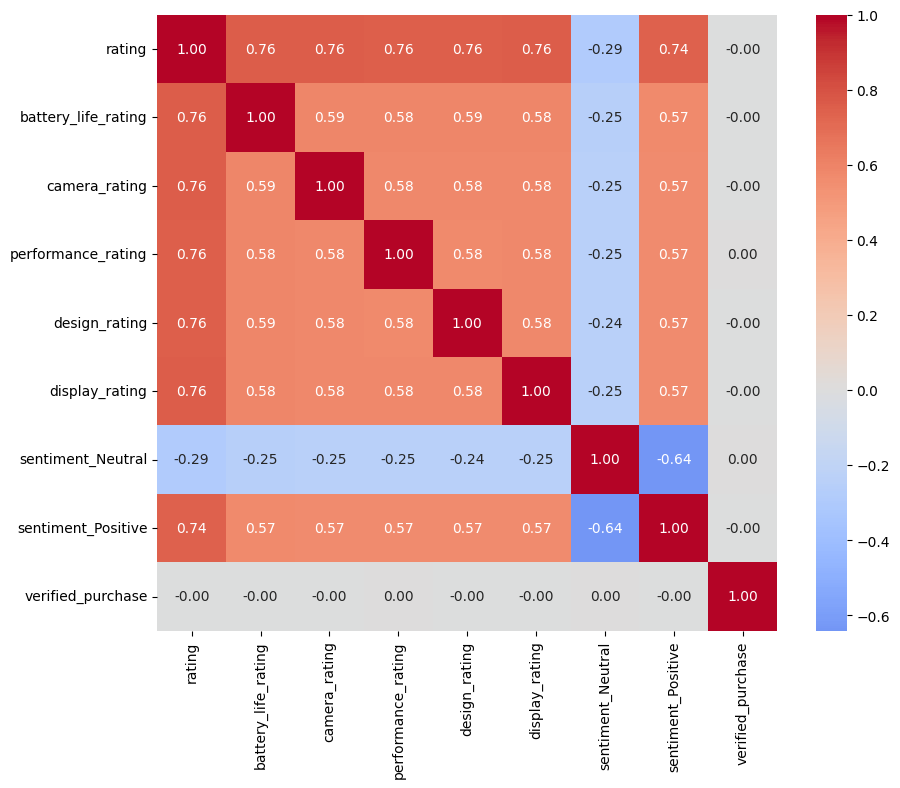

In [33]:
df_corr = X.copy()
df_corr["verified_purchase"] = y.astype(int)
corr_matrix = df_corr.corr(method="pearson")

corr_with_target = corr_matrix["verified_purchase"].sort_values(ascending=False)
print(corr_with_target)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    center=0
)
plt.show()

### Split del dataset

In [35]:
# X già numerico (dopo get_dummies)
y = df["verified_purchase"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_t = scaler.fit_transform(X_train)
X_test_t  = scaler.transform(X_test)

print("X_train:", X_train_t.shape, "X_test:", X_test_t.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)


X_train: (40000, 8) X_test: (10000, 8)
y_train: (40000,) y_test: (10000,)


### Scaling

In [36]:

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


### Rete neurale

In [ ]:

tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Input(shape=(X_train_s.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name="auc")]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

# Prima analisi

### differenze tra acquisti verificati e non verificati

vogliamo analizzare l'eventuale differenza tra recensioni con acquisti verificati e non.
Questo ci puo' aiutare a capire se le recensioni non verificate sono attendibili quanto quelle verificate.


In [46]:

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)

class_weight = {0: class_weights[0], 1: class_weights[1]}
print(class_weight)

{0: np.float64(2.5176233635448138), 1: np.float64(0.6239081607187422)}


In [48]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max",
        patience=20, restore_best_weights=True
    )
]
# dovrebbe fermarsi se capisce che l'AUC non migliora
model.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=256,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5474 - auc: 0.5346 - loss: 0.6917 - val_accuracy: 0.5539 - val_auc: 0.5007 - val_loss: 0.6885
Epoch 2/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5466 - auc: 0.5393 - loss: 0.6913 - val_accuracy: 0.5489 - val_auc: 0.4989 - val_loss: 0.6890
Epoch 3/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5440 - auc: 0.5425 - loss: 0.6909 - val_accuracy: 0.5505 - val_auc: 0.4988 - val_loss: 0.6882
Epoch 4/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5472 - auc: 0.5448 - loss: 0.6905 - val_accuracy: 0.5505 - val_auc: 0.4970 - val_loss: 0.6875
Epoch 5/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5487 - auc: 0.5475 - loss: 0.6903 - val_accuracy: 0.5474 - val_auc: 0.4974 - val_loss: 0.6871
Epoch 6/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5502 - auc: 0.5495 - loss: 0.6900 - val_accuracy: 0.5475 - val_auc: 0.4967 - val_loss: 0.6870
Epoch 7/200
125/125 ━━━━━━━━━━━━━━

### Confusion matrix

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, classification_report
logreg = LogisticRegression(
    class_weight="balanced",
    max_iter=2000
)

logreg.fit(X_train_s, y_train)

y_pred = logreg.predict(X_test_s)
confusion_matrix(y_test, y_pred)
p = logreg.predict_proba(X_test_s)[:,1]
print("AUC:", roc_auc_score(y_test, p))
print(classification_report(y_test, (p>=0.5).astype(int), digits=3))


AUC: 0.4966509389032436
              precision    recall  f1-score   support

           0      0.199     0.484     0.282      1986
           1      0.802     0.516     0.628      8014

    accuracy                          0.510     10000
   macro avg      0.500     0.500     0.455     10000
weighted avg      0.682     0.510     0.559     10000

